# Quickstart
Now that you installation went ok, let's start with a small example.
Let's create our first `Geodes` object.

In [1]:
from pygeodes import Geodes

geodes = Geodes()

## Searching for collections
Then we can start by searching for existing collections, for example with search term *sentinel* :

In [2]:
collections, dataframe = geodes.search_collections("sentinel")

D:\UE\4_Semester\code\scripts\pro_env\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'geodes-portal.cnes.fr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
Indexing: 100%|██████████| 66/66 [00:00<00:00, 3441.12it/s]


Let's see what we found. As a result, we get a `collections` object, which is a list of `Collection` objects.

In [3]:
collections

[<Collection id=THEIA_S1TILING_SENTINEL1_L1>,
 <Collection id=THEIA_BIOPHY_SENTINEL2_L2B>,
 <Collection id=THEIA_WATERQUAL_SENTINEL2_L2B>,
 <Collection id=THEIA_REFLECTANCE_SENTINEL2_L3A>,
 <Collection id=THEIA_REFLECTANCE_SENTINEL2_L2A>,
 <Collection id=PEPS_S2_L1C>,
 <Collection id=PEPS_S1_L2>,
 <Collection id=PEPS_S1_L1>,
 <Collection id=THEIA_SPOT4_TAKE5_L1C>,
 <Collection id=THEIA_REFLECTANCE_LANDSAT8_L2A>,
 <Collection id=THEIA_OSO_RASTER_L3B>,
 <Collection id=THEIA_REFLECTANCE_SPOT4_TAKE5_L2A>,
 <Collection id=PEPS_S3_L1>,
 <Collection id=THEIA_SPOT5_TAKE5_L1C>,
 <Collection id=THEIA_REFLECTANCE_SPOT5_TAKE5_L2A>,
 <Collection id=THEIA_OSO_VECTOR_L3B>]

and a `dataframe` object, which is a `geopandas.GeoDataFrame`.

In [4]:
dataframe

,title,description,collection
0,THEIA S1TILING SENTINEL L1,S1TILING L1 products are based on Sentinel-1 L...,<Collection id=THEIA_S1TILING_SENTINEL1_L1>
1,THEIA SENTINEL2 BIOPHY L2B,Biophysical variables characteristic of vegeta...,<Collection id=THEIA_BIOPHY_SENTINEL2_L2B>
2,THEIA WaterQual SENTINEL2 L2B,The processing chain outputs rasters of the co...,<Collection id=THEIA_WATERQUAL_SENTINEL2_L2B>
3,THEIA SENTINEL2 L3A,The products of level 3A provide a monthly syn...,<Collection id=THEIA_REFLECTANCE_SENTINEL2_L3A>
4,THEIA SENTINEL2 L2A,The level 2A products correct the data for atm...,<Collection id=THEIA_REFLECTANCE_SENTINEL2_L2A>
5,PEPS Sentinel-2 L1C tiles,Sentinel-2 L1C tiles acquisition and storage f...,<Collection id=PEPS_S2_L1C>
6,PEPS Sentinel-1 Level2,Sentinel-1 Level-2 consists of geolocated geop...,<Collection id=PEPS_S1_L2>
7,PEPS Sentinel-1 Level1,Sentinel-1 Level-1 products are the baseline p...,<Collection id=PEPS_S1_L1>
8,TAKE5 SPOT4 LEVEL1C,"At the end of life of each satellite, CNES iss...",<Collection id=THEIA_SPOT4_TAKE5_L1C>
9,THEIA LANDSAT8 L2A,The level 2A products correct the data for atm...,<Collection id=THEIA_REFLECTANCE_LANDSAT8_L2A>


The dataframe let's see you quickly see what you found, with only a few columns (here *description* and *title*), but if you are more comfortable working with raw objects, it's also possible.

Let's see how many elements are in these collections.

In [5]:
for collection in collections:
    print(
        f"collection {collection.title} has {collection.summaries.other.get('total_items')} elements"
    )

collection THEIA S1TILING SENTINEL L1 has 200044 elements
collection THEIA SENTINEL2 BIOPHY L2B has 1065 elements
collection THEIA WaterQual SENTINEL2 L2B has 138 elements
collection THEIA SENTINEL2 L3A has 106687 elements
collection THEIA SENTINEL2 L2A has 2631090 elements
collection PEPS Sentinel-2 L1C tiles has 39871404 elements
collection PEPS Sentinel-1 Level2 has 1642946 elements
collection PEPS Sentinel-1 Level1 has 6776411 elements
collection TAKE5 SPOT4 LEVEL1C has 902 elements
collection THEIA LANDSAT8 L2A has 27896 elements
collection THEIA OSO RASTER has 9 elements
collection TAKE5 SPOT4 LEVEL2A has 814 elements
collection GDH Sentinel-3 L1 STM Level-1 products has 72195 elements
collection TAKE5 SPOT5 LEVEL1C has 3740 elements
collection TAKE5 SPOT5 LEVEL2A has 2953 elements
collection THEIA OSO VECTOR has 864 elements


We could want to add columns to our dataframe. To know which columns are available, use `collection.list_available_keys()` on a `Collection` object : 

In [6]:
collections[3].list_available_keys()

{'assets.soilr.description',
 'assets.soilr.href',
 'assets.soilr.roles',
 'assets.soilr.title',
 'assets.soilr.type',
 'assets.wms_capabilities.description',
 'assets.wms_capabilities.href',
 'assets.wms_capabilities.roles',
 'assets.wms_capabilities.title',
 'assets.wms_capabilities.type',
 'description',
 'extent.spatial.bbox',
 'extent.temporal.interval',
 'id',
 'keywords',
 'license',
 'links',
 'providers',
 'stac_extensions',
 'stac_version',
 'summaries.access_url',
 'summaries.constellation',
 'summaries.contact_email',
 'summaries.contact_name',
 'summaries.dataset',
 'summaries.format',
 'summaries.geometry_type',
 'summaries.gsd',
 'summaries.instruments',
 'summaries.item_type',
 'summaries.latest',
 'summaries.missions',
 'summaries.platform',
 'summaries.processing:level',
 'summaries.temporal_resolution',
 'summaries.theme',
 'summaries.total_items',
 'summaries.variables',
 'summaries.version',
 'title',
 'type'}

Let's add `summaries.total_items` to the dataframe : 

In [7]:
from pygeodes.utils.formatting import format_collections

new_dataframe = format_collections(
    dataframe, columns_to_add={"summaries.total_items"}
)

In [8]:
new_dataframe

,title,description,collection,summaries.total_items
0,THEIA S1TILING SENTINEL L1,S1TILING L1 products are based on Sentinel-1 L...,<Collection id=THEIA_S1TILING_SENTINEL1_L1>,0
1,THEIA SENTINEL2 BIOPHY L2B,Biophysical variables characteristic of vegeta...,<Collection id=THEIA_BIOPHY_SENTINEL2_L2B>,0
2,THEIA WaterQual SENTINEL2 L2B,The processing chain outputs rasters of the co...,<Collection id=THEIA_WATERQUAL_SENTINEL2_L2B>,138
3,THEIA SENTINEL2 L3A,The products of level 3A provide a monthly syn...,<Collection id=THEIA_REFLECTANCE_SENTINEL2_L3A>,63568
4,THEIA SENTINEL2 L2A,The level 2A products correct the data for atm...,<Collection id=THEIA_REFLECTANCE_SENTINEL2_L2A>,2177670
5,PEPS Sentinel-2 L1C tiles,Sentinel-2 L1C tiles acquisition and storage f...,<Collection id=PEPS_S2_L1C>,37010592
6,PEPS Sentinel-1 Level2,Sentinel-1 Level-2 consists of geolocated geop...,<Collection id=PEPS_S1_L2>,1534336
7,PEPS Sentinel-1 Level1,Sentinel-1 Level-1 products are the baseline p...,<Collection id=PEPS_S1_L1>,6441578
8,TAKE5 SPOT4 LEVEL1C,"At the end of life of each satellite, CNES iss...",<Collection id=THEIA_SPOT4_TAKE5_L1C>,902
9,THEIA LANDSAT8 L2A,The level 2A products correct the data for atm...,<Collection id=THEIA_REFLECTANCE_LANDSAT8_L2A>,27896


If you wish to produce a fresh new dataframe with your custom columns, use `format_collections` on a list of collections :  

In [9]:
new_dataframe = format_collections(
    collections,
    columns_to_add={"summaries.constellation", "summaries.instruments"},
)

In [10]:
new_dataframe

,summaries.constellation,summaries.instruments,title,description,collection
0,[sentinel-1],[SAR],THEIA S1TILING SENTINEL L1,S1TILING L1 products are based on Sentinel-1 L...,<Collection id=THEIA_S1TILING_SENTINEL1_L1>
1,[sentinel-2],[MSI],THEIA SENTINEL2 BIOPHY L2B,Biophysical variables characteristic of vegeta...,<Collection id=THEIA_BIOPHY_SENTINEL2_L2B>
2,[sentinel-2],[],THEIA WaterQual SENTINEL2 L2B,The processing chain outputs rasters of the co...,<Collection id=THEIA_WATERQUAL_SENTINEL2_L2B>
3,[sentinel-2],[MSI],THEIA SENTINEL2 L3A,The products of level 3A provide a monthly syn...,<Collection id=THEIA_REFLECTANCE_SENTINEL2_L3A>
4,[sentinel-2],[MSI],THEIA SENTINEL2 L2A,The level 2A products correct the data for atm...,<Collection id=THEIA_REFLECTANCE_SENTINEL2_L2A>
5,[sentinel-2],[MSI],PEPS Sentinel-2 L1C tiles,Sentinel-2 L1C tiles acquisition and storage f...,<Collection id=PEPS_S2_L1C>
6,[sentinel-1],[SAR-C],PEPS Sentinel-1 Level2,Sentinel-1 Level-2 consists of geolocated geop...,<Collection id=PEPS_S1_L2>
7,[sentinel-1],[SAR-C],PEPS Sentinel-1 Level1,Sentinel-1 Level-1 products are the baseline p...,<Collection id=PEPS_S1_L1>
8,[spot-4],"[HRV, HRVIR]",TAKE5 SPOT4 LEVEL1C,"At the end of life of each satellite, CNES iss...",<Collection id=THEIA_SPOT4_TAKE5_L1C>
9,[landsat-8],[OLI],THEIA LANDSAT8 L2A,The level 2A products correct the data for atm...,<Collection id=THEIA_REFLECTANCE_LANDSAT8_L2A>


**Note** : `title` and `description` columns are always here by default. 

## Searching for items

As for collections, we can search for items.
To know which arguments to put in your query, please use : 



In [7]:
from pygeodes.utils.query import get_requestable_args

print(get_requestable_args())

{'version': 'v8.0', 'attributes': ['dataset (STRING)', 'datetime (DATE_ISO8601)', 'links (STRING)', 'product_validity (BOOLEAN)', 'sci:doi (STRING_ARRAY)', 'no_geometry (BOOLEAN)', 'start_datetime (DATE_ISO8601)', 'end_datetime (DATE_ISO8601)', 'processing:datetime (DATE_ISO8601)', 'processing:lineage (STRING)', 'processing_context (STRING)', 'processing_correction (STRING)', 'processing:version (STRING)', 'bbox (STRING)', 'nb_cols (STRING)', 'nb_rows (STRING)', 'instrument (STRING)', 'platform (STRING)', 'sar:instrument_mode (STRING)', 'processing:level (STRING)', 'sar:polarizations (STRING)', 'sat:orbit_cycle (INTEGER)', 'mission_take_id (INTEGER)', 's2:datatake_id (STRING)', 'sat:relative_orbit (INTEGER)', 'sat:absolute_orbit (LONG)', 'sat:orbit_state (STRING)', 'product:type (STRING)', 'parameter (STRING)', 'pparameter (STRING)', 'product (STRING)', 'temporal_resolution (STRING)', 'classification (STRING)', 'swath (STRING)', 'bands (STRING)', 'grid:code (STRING)', 'eo:cloud_cover (

In [34]:
query = {
    "grid:code": {"eq": "T32UNC"},
    "start_datetime": {
        "gte": "2024-03-01T00:00:00Z",
        "lte": "2024-03-30T23:59:59Z"
    }
}

items, dataframe = geodes.search_items(
    query=query,
    sortBy=[{"direction": "desc", "field": "start_datetime"}],
    collections=["THEIA_REFLECTANCE_SENTINEL2_L3A"]
)

D:\UE\4_Semester\code\scripts\pro_env\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'geodes-portal.cnes.fr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Found 1 items matching your query, returning 1 as get_all parameter is set to False
1 item(s) found for query : {'grid:code': {'eq': 'T32UNC'}, 'start_datetime': {'gte': '2024-03-01T00:00:00Z', 'lte': '2024-03-30T23:59:59Z'}}



Again, we come out with an `items` object, and a `dataframe` object.

In [37]:
items[:10]  # printing everything is useless

[Item (URN:FEATURE:DATA:gdh:20fd873c-0659-3530-a47f-f6dfd4803ce7:V1)]

In [38]:
dataframe

,grid:code,collection,id,start_datetime,item,geometry
0,T32UNC,THEIA_REFLECTANCE_SENTINEL2_L3A,URN:FEATURE:DATA:gdh:20fd873c-0659-3530-a47f-f...,2024-03-15T00:00:00Z,Item (URN:FEATURE:DATA:gdh:20fd873c-0659-3530-...,"POLYGON ((8.99971 52.35047, 8.99971 51.36324, ..."


In [15]:
##Folim is required for the command below. You can install in your Python environment by executing pip install "folium>=0.12" matplotlib mapclassify
m = dataframe.explore()

In [23]:
import base64
from IPython.display import display, HTML

map_html = m._repr_html_()
b64_html = base64.b64encode(map_html.encode('utf-8')).decode('utf-8')
iframe_src = f"data:text/html;base64,{b64_html}"

# 4. Display the isolated map frame
display(HTML(f'<iframe src="{iframe_src}" width="100%" height="500px" style="border:none;"></iframe>'))

c:\Program Files\Positron\resources\app\extensions\positron-python\python_files\lib\ipykernel\py3\IPython\core\display.py:431: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## Providing an api key
The next parts involve requests that require an api-key. You can register one using the following method. We will also set a default download directory, for later. We use a file `config.json` formed as follows : 

```json
{"api_key" : "MyApiKey","download_dir" : "/tmp"}
```

In [26]:
from pygeodes import Config

conf = Config.from_file("config.json")
geodes.set_conf(conf)

## Quicklook
Now we can have a look at our items.

Quicklook of Item (URN:FEATURE:DATA:gdh:20fd873c-0659-3530-a47f-f6dfd4803ce7:V1)


D:\UE\4_Semester\code\scripts\pro_env\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'geodes-portal.cnes.fr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


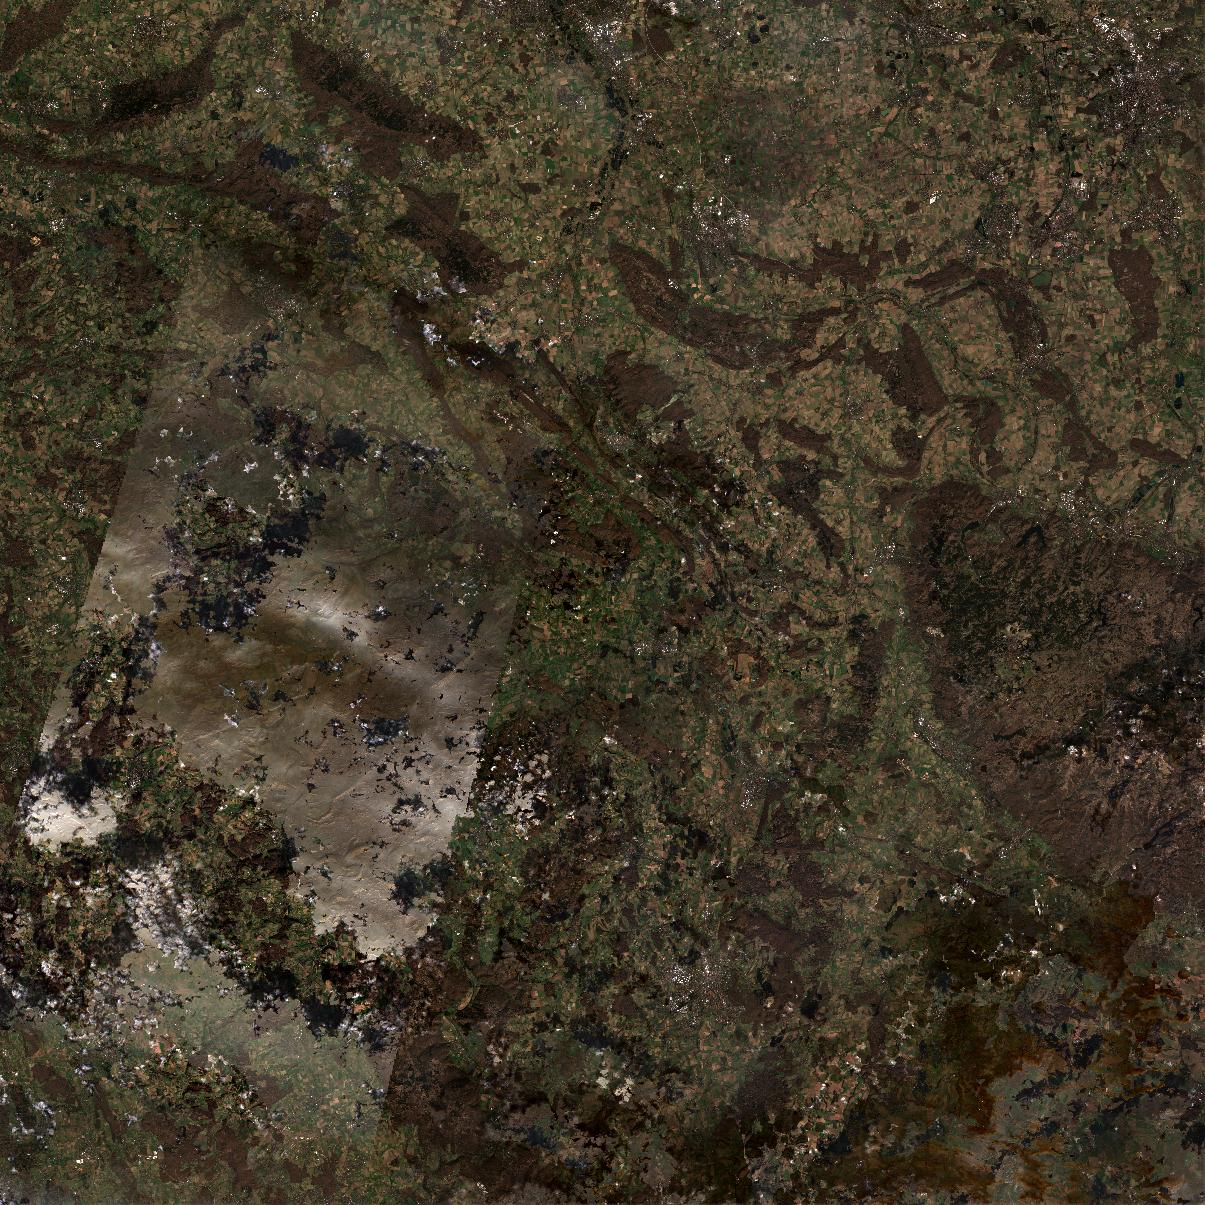

In [39]:
for item in dataframe["item"]:
    print(f"Quicklook of {item}")
    item.show_quicklook()

## Downloading items

Now we could want to download these items for further use :

In [40]:
for item in dataframe["item"]:
    #print(item)
    item.download_archive()

D:\UE\4_Semester\code\scripts\pro_env\Lib\site-packages\urllib3\connectionpool.py:1110: InsecureRequestWarning: Unverified HTTPS request is being made to host 'geodes-portal.cnes.fr'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


ChunkedEncodingError: ('Connection broken: IncompleteRead(542649814 bytes read, 587438248 more expected)', IncompleteRead(542649814 bytes read, 587438248 more expected))

As we provided `/tmp` as default download dir, the downloads are stored in this folder.